# Panel Degradation Detection Prototype

## Objective

This notebook builds a prototype model for detecting solar panel degradation using the existing Omni-Grid style SCADA and weather dataset.

The model follows this logic:

1. Predict expected solar generation under normal conditions.
2. Compare expected generation with actual generation.
3. Calculate residuals and performance loss.
4. Engineer rolling degradation features.
5. Classify degradation severity.
6. Evaluate model performance.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBRegressor, XGBClassifier

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Dataset

In this section, we load the existing Omni-Grid style dataset that contains solar generation, weather, and SCADA telemetry features.

In [2]:
# Load dataset
df = pd.read_csv("synthetic_predictive_maintenance_dataset.csv")

# Preview dataset
df.head()

,date,inverter_id,manufacturer,climate_zone,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,dust_soiling_index,uv_exposure_index,cumulative_uv_exposure,operating_hours_today,cumulative_operating_hours,cumulative_energy_throughput_mwh,efficiency_pct,reactive_power_capability,internal_temperature_c,voltage_ripple,current_harmonic_distortion_pct,insulation_resistance_mohm,capacitor_degradation_indicator,fan_speed_rpm,restart_count_today,error_code_count_today,thermal_cycling_count_today,overload_events_today,failure_within_7d,failure_within_30d,failure_within_90d,rul_days,failed_today,is_censored,efficiency_7d_mean,efficiency_30d_mean,temperature_7d_mean,temperature_30d_mean,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum
0,2025-01-01,INV-0001,Fronius,Temperate,100,0.789,0.88,83.00,19.57,40.05,0.292,6.43,6.43,11.78,11.78,1.161,97.93,1.057,28.51,2.631,5.431,79.04,0.427,2676.3,0,0,3,0,0,0,0,127.0,0,0,97.9300,97.9300,28.510000,28.510000,0.0000,0.0,0.0,0.0
1,2025-01-02,INV-0001,Fronius,Temperate,100,0.789,0.88,83.03,23.48,41.48,0.346,6.33,12.76,12.30,24.08,2.112,97.46,1.076,36.64,2.569,5.509,77.96,0.383,2573.1,0,0,0,0,0,0,0,126.0,0,0,97.6950,97.6950,32.575000,32.575000,-0.2350,0.0,0.0,0.0
2,2025-01-03,INV-0001,Fronius,Temperate,100,0.789,0.88,83.07,21.69,45.80,0.329,7.88,20.64,12.34,36.42,2.967,98.04,0.958,32.22,3.072,5.553,80.58,0.295,2865.0,0,0,0,0,0,0,0,125.0,0,0,97.8100,97.8100,32.456667,32.456667,0.2300,0.0,0.0,0.0
3,2025-01-04,INV-0001,Fronius,Temperate,100,0.789,0.88,83.10,21.43,22.49,0.186,7.09,27.74,10.41,46.83,3.794,97.48,1.039,35.10,2.268,5.643,76.89,0.502,2451.1,0,0,4,1,0,0,0,124.0,0,0,97.7275,97.7275,33.117500,33.117500,-0.2475,0.0,0.0,0.0
4,2025-01-05,INV-0001,Fronius,Temperate,100,0.789,0.88,83.13,23.25,33.41,0.368,6.04,33.78,14.66,61.49,5.075,98.43,0.926,36.49,2.869,5.472,82.03,0.367,2605.3,0,0,0,0,0,0,0,123.0,0,0,97.8680,97.8680,33.792000,33.792000,0.5620,0.0,0.0,0.0


## 2. Dataset Inspection

We inspect the dataset structure, feature names, data types, missing values, and summary statistics before preprocessing and feature engineering.

In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:\n")
print(df.columns.tolist())

Dataset Shape: (32627, 42)

Column Names:

['date', 'inverter_id', 'manufacturer', 'climate_zone', 'rated_capacity_kw', 'installation_quality_score', 'maintenance_quality_score', 'age_months', 'ambient_temperature_c', 'humidity_pct', 'dust_soiling_index', 'uv_exposure_index', 'cumulative_uv_exposure', 'operating_hours_today', 'cumulative_operating_hours', 'cumulative_energy_throughput_mwh', 'efficiency_pct', 'reactive_power_capability', 'internal_temperature_c', 'voltage_ripple', 'current_harmonic_distortion_pct', 'insulation_resistance_mohm', 'capacitor_degradation_indicator', 'fan_speed_rpm', 'restart_count_today', 'error_code_count_today', 'thermal_cycling_count_today', 'overload_events_today', 'failure_within_7d', 'failure_within_30d', 'failure_within_90d', 'rul_days', 'failed_today', 'is_censored', 'efficiency_7d_mean', 'efficiency_30d_mean', 'temperature_7d_mean', 'temperature_30d_mean', 'efficiency_decline_7d', 'temp_stress_index', 'restart_7d_sum', 'errors_7d_sum']


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32627 entries, 0 to 32626
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              32627 non-null  object 
 1   inverter_id                       32627 non-null  object 
 2   manufacturer                      32627 non-null  object 
 3   climate_zone                      32627 non-null  object 
 4   rated_capacity_kw                 32627 non-null  int64  
 5   installation_quality_score        32627 non-null  float64
 6   maintenance_quality_score         32627 non-null  float64
 7   age_months                        32627 non-null  float64
 8   ambient_temperature_c             32627 non-null  float64
 9   humidity_pct                      32627 non-null  float64
 10  dust_soiling_index                32627 non-null  float64
 11  uv_exposure_index                 32627 non-null  float64
 12  cumu

In [5]:
# Summary statistics
df.describe()

,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,dust_soiling_index,uv_exposure_index,cumulative_uv_exposure,operating_hours_today,cumulative_operating_hours,cumulative_energy_throughput_mwh,efficiency_pct,reactive_power_capability,internal_temperature_c,voltage_ripple,current_harmonic_distortion_pct,insulation_resistance_mohm,capacitor_degradation_indicator,fan_speed_rpm,restart_count_today,error_code_count_today,thermal_cycling_count_today,overload_events_today,failure_within_7d,failure_within_30d,failure_within_90d,rul_days,failed_today,is_censored,efficiency_7d_mean,efficiency_30d_mean,temperature_7d_mean,temperature_30d_mean,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum
count,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,15472.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000,32627.000000
mean,118.523769,0.877553,0.855399,72.085643,25.010567,56.805569,0.428357,6.190726,960.579651,11.506681,1785.516134,192.131059,97.088746,0.981589,36.222312,2.601263,5.165739,81.577975,0.444834,2673.705373,0.334876,0.445735,1.338523,0.502498,0.017869,0.069329,0.198854,123.288521,0.002207,0.525792,97.140224,97.314806,36.163191,35.975389,-0.051478,1.011626,2.248475,2.990529
std,69.349305,0.070556,0.083844,30.464418,5.297533,17.285942,0.178572,1.392645,622.355705,1.205308,1153.847684,185.288272,1.994811,0.065462,6.081014,0.763142,1.479057,7.365598,0.156228,334.247683,0.719017,0.890407,1.412956,0.865052,0.132476,0.254017,0.399144,84.304886,0.046925,0.499342,1.850374,1.514453,3.349803,2.624110,0.482447,2.389470,3.254017,4.314479
min,50.000000,0.760000,0.706000,12.000000,1.670000,10.000000,0.000000,1.000000,3.230000,6.490000,8.940000,0.386000,88.430000,0.675000,20.000000,0.552000,1.096000,58.030000,0.005000,1200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89.580000,90.775000,21.280000,21.280000,-1.910000,0.000000,0.000000,0.000000
25%,75.000000,0.816000,0.779000,46.800000,21.450000,43.770000,0.299000,5.250000,424.790000,10.700000,793.100000,64.555500,97.170000,0.946000,32.090000,2.026000,4.051000,75.970000,0.342000,2459.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,53.000000,0.000000,0.000000,97.535714,97.619833,33.794286,34.067167,-0.375714,0.000000,0.000000,1.000000
50%,100.000000,0.879000,0.859000,71.900000,25.000000,56.590000,0.402000,6.190000,888.310000,11.510000,1653.140000,136.351000,97.740000,0.988000,36.110000,2.596000,5.173000,81.390000,0.421000,2686.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,111.000000,0.000000,1.000000,97.828571,97.862000,35.752857,35.155500,-0.047143,0.000000,1.000000,2.000000
75%,150.000000,0.941000,0.929000,95.930000,28.580000,69.770000,0.544500,7.130000,1441.830000,12.330000,2682.615000,252.303000,98.170000,1.026000,40.180000,3.137000,6.225000,87.320000,0.512000,2903.400000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,184.000000,0.000000,1.000000,98.027143,98.002667,38.152857,37.920167,0.274286,0.180000,2.000000,3.000000
max,250.000000,1.000000,0.999000,131.130000,45.050000,100.000000,1.000000,10.000000,2342.420000,15.000000,4240.340000,962.655000,99.500000,1.100000,63.220000,5.749000,10.754000,102.140000,1.000000,3800.000000,8.000000,9.000000,12.000000,8.000000,1.000000,1.000000,1.000000,365.000000,1.000000,1.000000,99.170000,99.170000,51.565714,49.240000,1.822857,23.220000,24.000000,32.000000


## 3. Missing Value Analysis

This step checks whether the dataset contains missing values that may affect model training or feature engineering.

In [6]:
# Missing value check
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

rul_days    17155
dtype: int64


## 4. Exploratory Data Analysis

We perform initial exploratory analysis to understand the distributions and relationships between operational variables relevant to panel degradation.

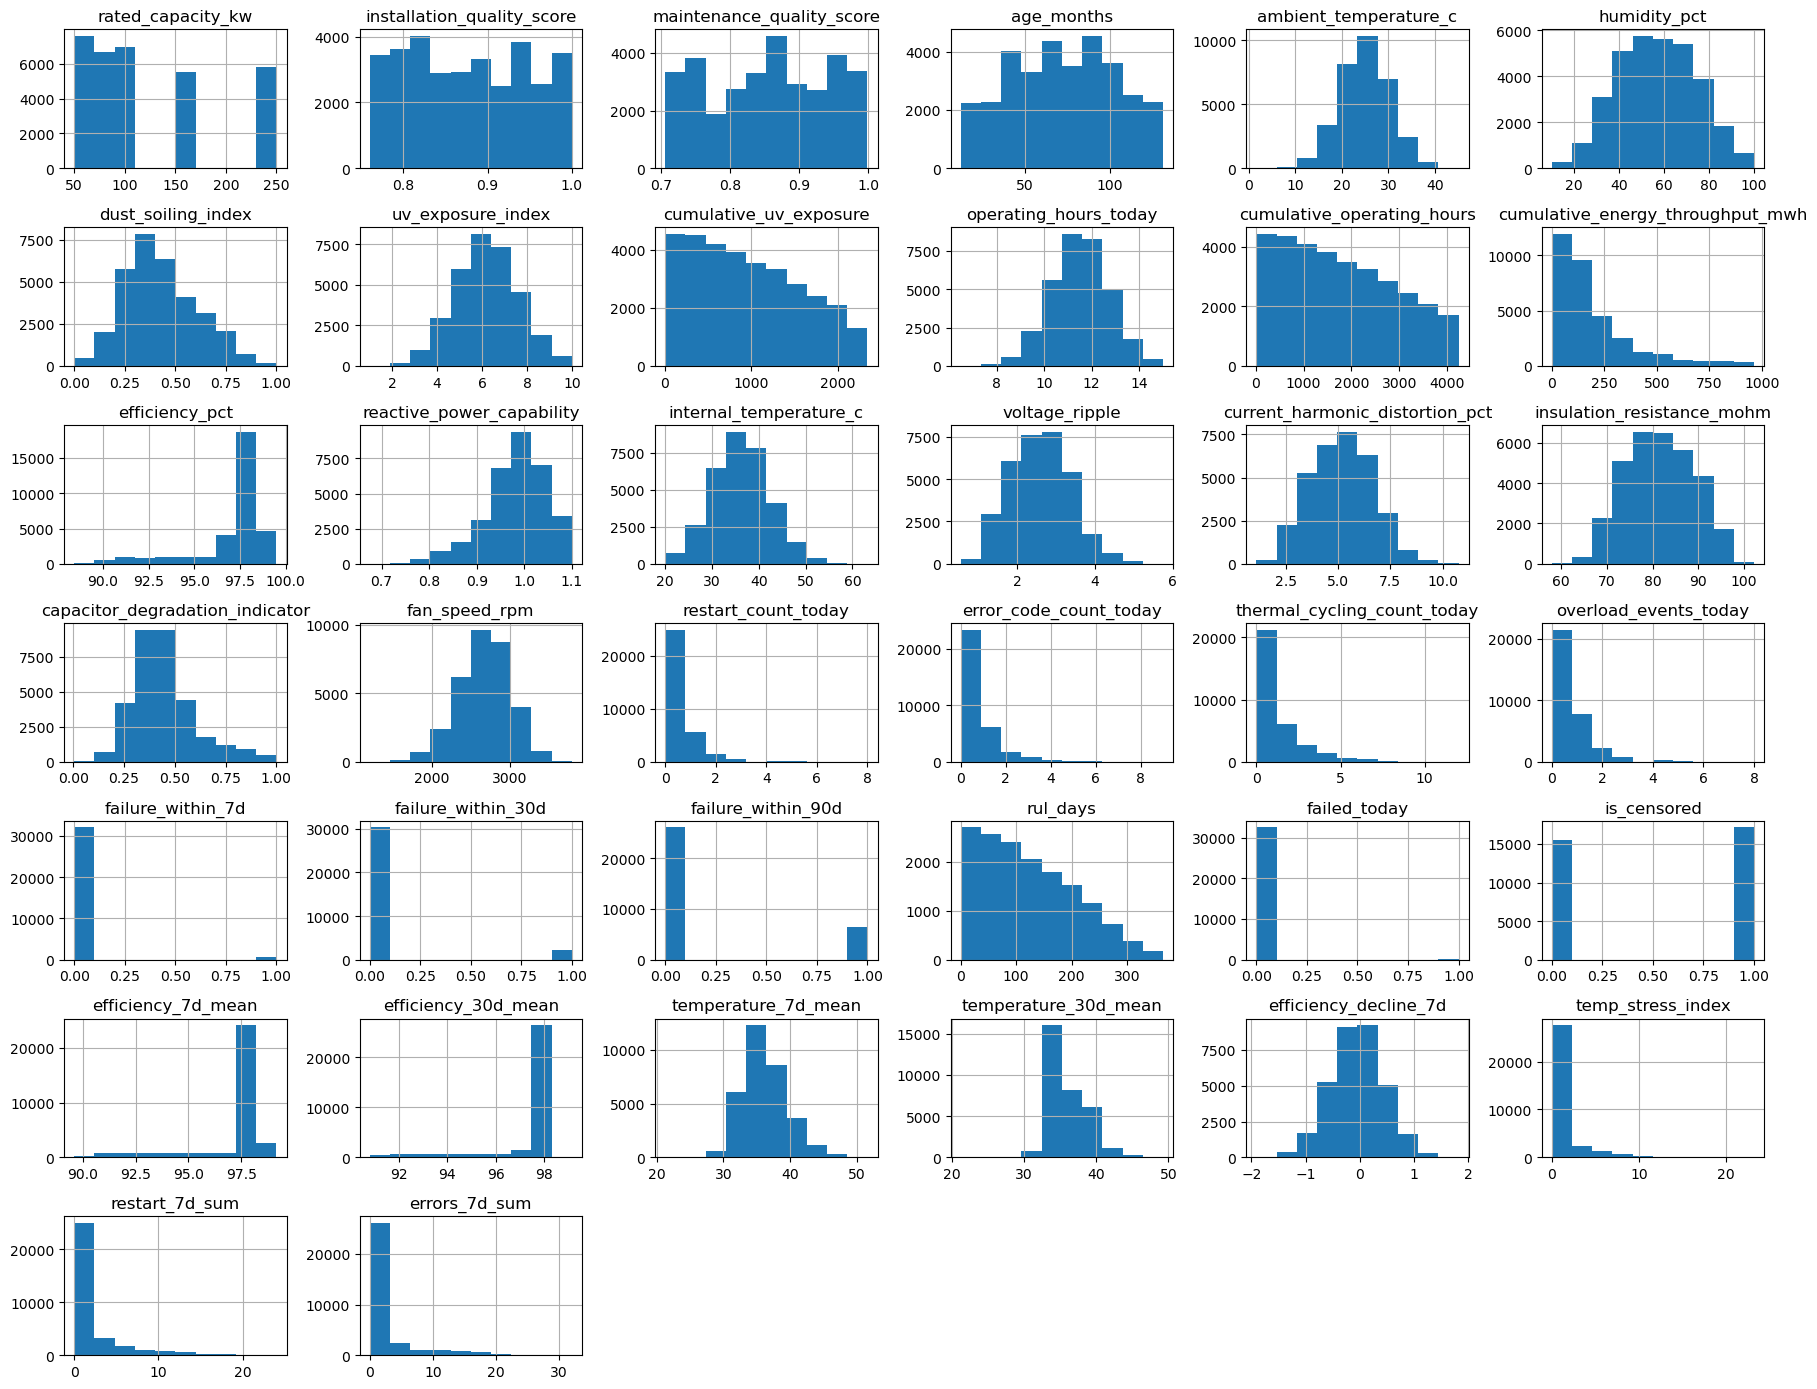

In [7]:
# Numerical feature distributions
df.hist(figsize=(18, 14))
plt.tight_layout()
plt.show()

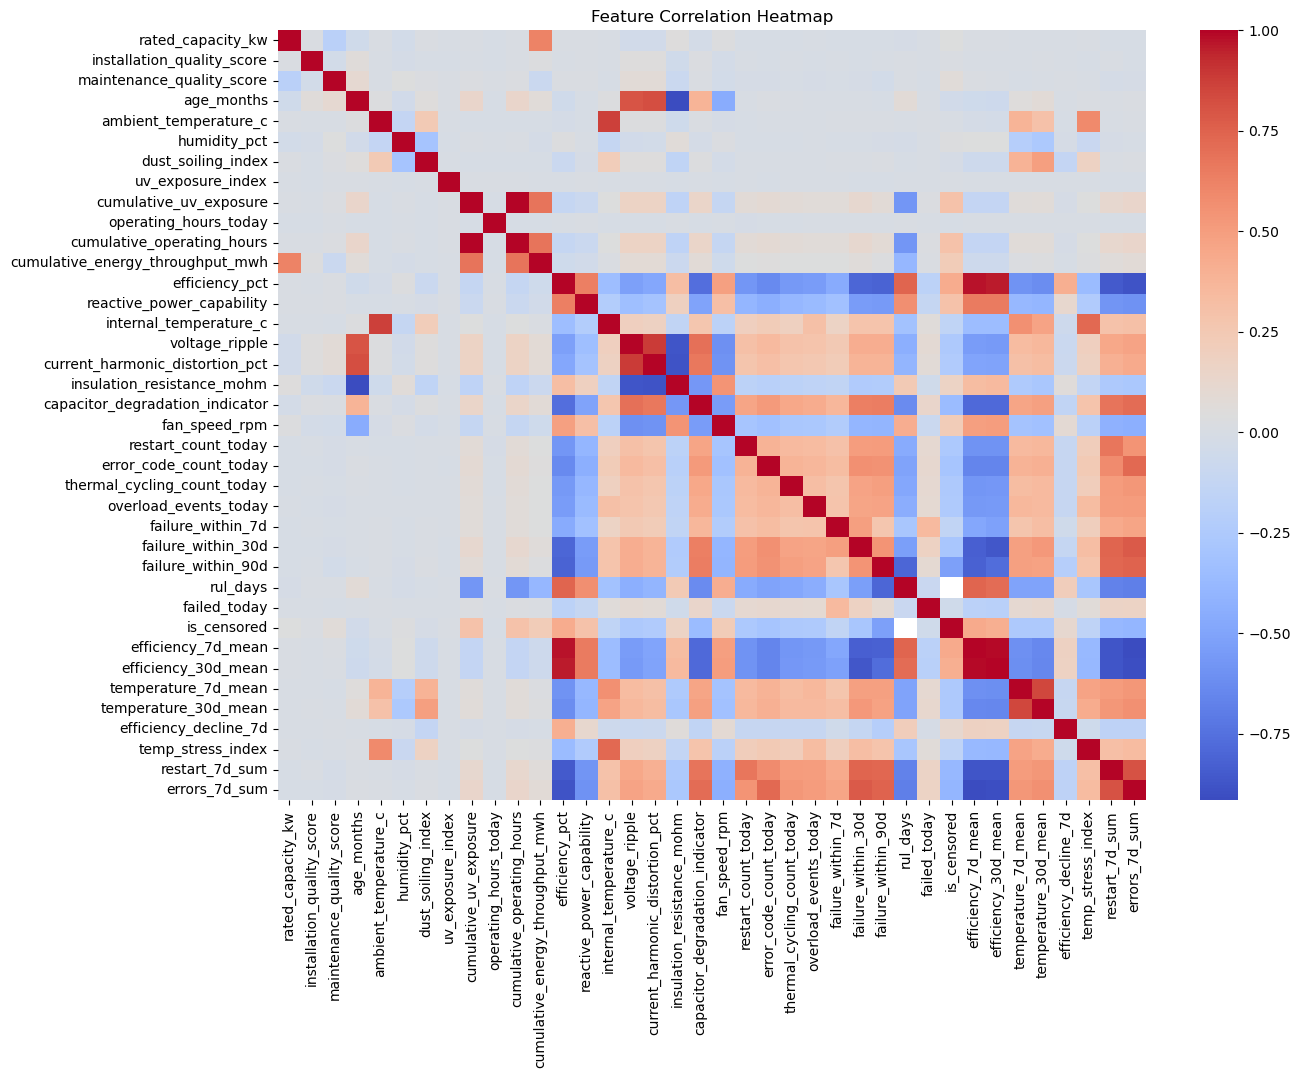

In [8]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)

plt.title("Feature Correlation Heatmap")
plt.show()

## 5. Synthetic Panel Degradation Simulation

Since real labelled panel degradation data is limited, synthetic degradation behaviour is generated using operational efficiency decline patterns and performance reduction logic.

In [9]:
# Create synthetic degradation score

np.random.seed(42)

df['degradation_score'] = (
    (100 - df['efficiency_pct']) * 0.35 +
    df['internal_temperature_c'] * 0.15 +
    df['voltage_ripple'] * 0.20 +
    df['current_harmonic_distortion_pct'] * 0.15 +
    df['dust_soiling_index'] * 0.10 +
    df['temp_stress_index'] * 0.05 +
    np.random.normal(0, 1, len(df))
)

# Normalize degradation score between 0 and 1
df['degradation_score'] = (
    (df['degradation_score'] - df['degradation_score'].min()) /
    (df['degradation_score'].max() - df['degradation_score'].min())
)

# Preview results
df[['efficiency_pct',
    'internal_temperature_c',
    'voltage_ripple',
    'dust_soiling_index',
    'degradation_score']].head()

,efficiency_pct,internal_temperature_c,voltage_ripple,dust_soiling_index,degradation_score
0,97.93,28.51,2.631,0.292,0.312718
1,97.46,36.64,2.569,0.346,0.359871
2,98.04,32.22,3.072,0.329,0.361464
3,97.48,35.10,2.268,0.186,0.445403
4,98.43,36.49,2.869,0.368,0.334770


## 6. Degradation Severity Classification

The continuous degradation score is converted into severity categories representing different levels of operational risk and panel efficiency decline.

In [12]:
# Create degradation categories

conditions = [
    (df['degradation_score'] <= 0.25),
    (df['degradation_score'] > 0.25) & (df['degradation_score'] <= 0.50),
    (df['degradation_score'] > 0.50) & (df['degradation_score'] <= 0.75),
    (df['degradation_score'] > 0.75)
]

labels = ['Low', 'Mild', 'Moderate', 'High']

df['degradation_level'] = np.select(
    conditions,
    labels,
    default='Unknown'
)

# Distribution of degradation levels
df['degradation_level'].value_counts()

degradation_level
Mild        24184
Moderate     4141
Low          4109
High          193
Name: count, dtype: int64

## 7. Feature Selection

Relevant operational, environmental, thermal, and electrical features are selected for degradation prediction modelling.

In [13]:
# Selected features

features = [
    'ambient_temperature_c',
    'humidity_pct',
    'dust_soiling_index',
    'uv_exposure_index',
    'efficiency_pct',
    'internal_temperature_c',
    'voltage_ripple',
    'current_harmonic_distortion_pct',
    'thermal_cycling_count_today',
    'efficiency_7d_mean',
    'efficiency_30d_mean',
    'temperature_7d_mean',
    'temperature_30d_mean',
    'efficiency_decline_7d',
    'temp_stress_index',
    'restart_7d_sum',
    'errors_7d_sum'
]

X = df[features]

# Target
y = df['degradation_score']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (32627, 17)


## 8. Train-Test Split

The dataset is divided into training and testing subsets to evaluate model generalisation performance.

In [14]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (26101, 17)
Testing set shape: (6526, 17)


## 9. Train XGBoost Regression Model

An XGBoost Regressor is trained to predict the degradation score using selected environmental, thermal, electrical, and operational features.

In [15]:
# Train XGBoost regression model

xgb_regressor = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

xgb_regressor.fit(X_train, y_train)

print("XGBoost regression model trained successfully.")

XGBoost regression model trained successfully.


## 10. Generate Model Predictions

The trained model is used to predict degradation scores on the test dataset.

In [16]:
# Generate predictions

y_pred = xgb_regressor.predict(X_test)

# Preview predictions
prediction_results = pd.DataFrame({
    'Actual_Degradation_Score': y_test.values,
    'Predicted_Degradation_Score': y_pred
})

prediction_results.head()

,Actual_Degradation_Score,Predicted_Degradation_Score
0,0.511308,0.375180
1,0.515941,0.441758
2,0.433654,0.276793
3,0.319706,0.335869
4,0.597937,0.466015


## 11. Regression Model Evaluation

The model is evaluated using MAE, RMSE, R² Score, and MAPE to measure degradation score prediction accuracy.

In [17]:
# Regression evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print("Regression Model Performance")
print("----------------------------")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

Regression Model Performance
----------------------------
MAE:  0.0507
RMSE: 0.0637
R²:   0.7142
MAPE: 15.91%


## 12. Actual vs Predicted Degradation Scores

This visualisation compares the actual degradation scores against the model predictions to evaluate prediction accuracy and trend alignment.

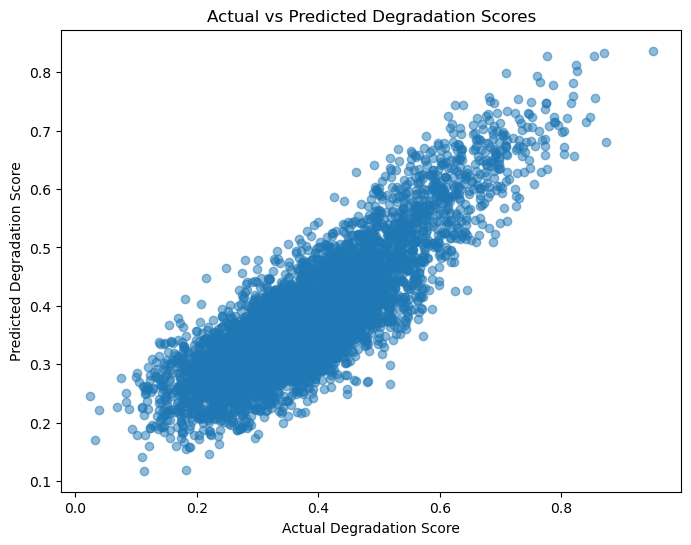

In [19]:
# Actual vs Predicted scatter plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Degradation Score")
plt.ylabel("Predicted Degradation Score")
plt.title("Actual vs Predicted Degradation Scores")

plt.show()

## 13. Residual Analysis

Residual analysis is used to evaluate prediction error distribution and identify potential systematic underprediction or overprediction behaviour.

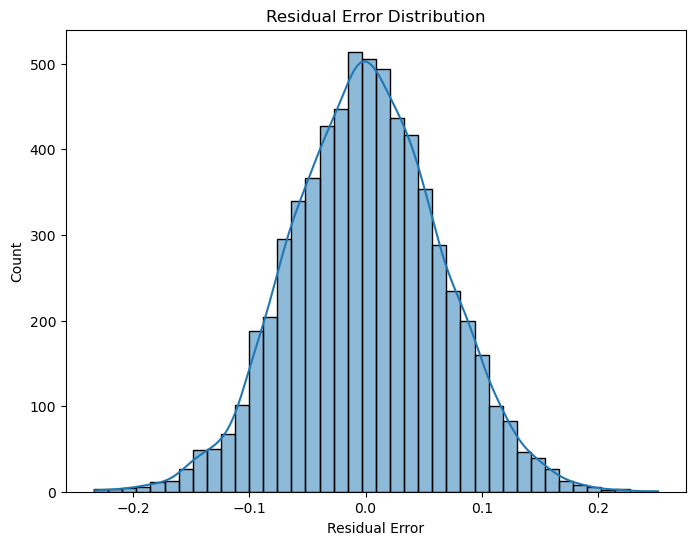

In [20]:
# Calculate residuals

residuals = y_test - y_pred

# Residual distribution

plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.xlabel("Residual Error")
plt.title("Residual Error Distribution")

plt.show()

## 14. Feature Importance Analysis

Feature importance analysis identifies the operational and environmental variables that contribute most strongly to degradation prediction.

In [21]:
# Extract feature importance

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_regressor.feature_importances_
})

# Sort importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
4,efficiency_pct,0.347833
5,internal_temperature_c,0.238854
14,temp_stress_index,0.186290
9,efficiency_7d_mean,0.079454
10,efficiency_30d_mean,0.044585
7,current_harmonic_distortion_pct,0.026198
6,voltage_ripple,0.021783
13,efficiency_decline_7d,0.006629
11,temperature_7d_mean,0.006039
12,temperature_30d_mean,0.005761


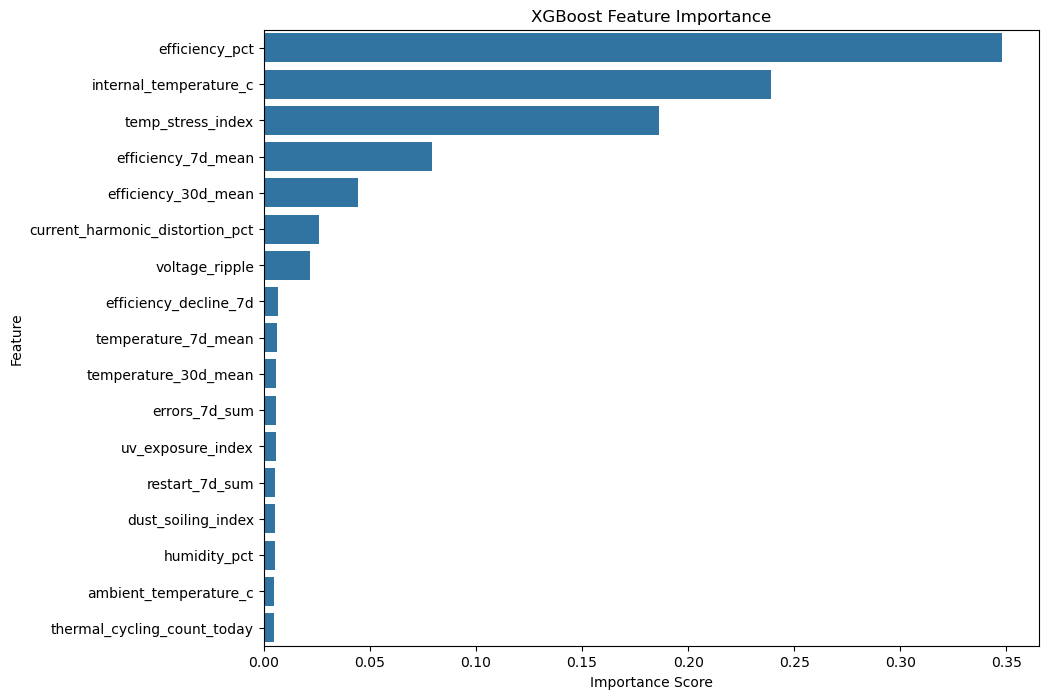

In [22]:
# Plot feature importance

plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## 15. Degradation Severity Distribution

This section visualises the distribution of degradation severity levels across the dataset.

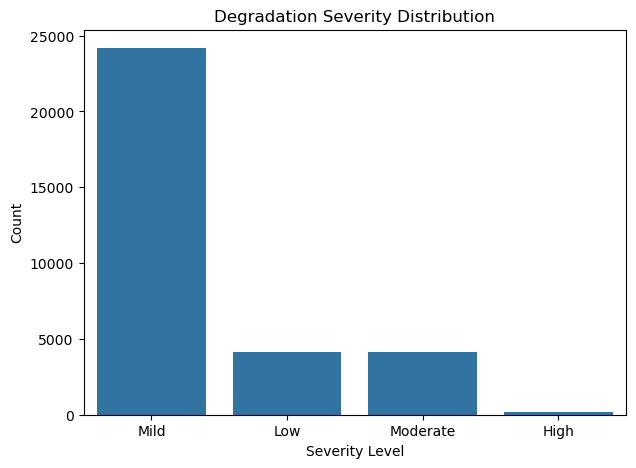

In [23]:
# Severity distribution plot

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='degradation_level'
)

plt.title("Degradation Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")

plt.show()

## 16. Classification-Based Degradation Detection

The continuous degradation scores are converted into severity classes to simulate operational degradation alerting and maintenance prioritisation workflows.

In [24]:
# Convert predictions into degradation classes

def classify_degradation(score):

    if score <= 0.25:
        return "Low"

    elif score <= 0.50:
        return "Mild"

    elif score <= 0.75:
        return "Moderate"

    else:
        return "High"

# Actual classes
y_test_class = y_test.apply(classify_degradation)

# Predicted classes
y_pred_class = pd.Series(y_pred).apply(classify_degradation)

## 17. Classification Performance Evaluation

Classification metrics are used to evaluate the model’s ability to correctly identify degradation severity categories.

In [26]:
# Classification metrics

precision = precision_score(
    y_test_class,
    y_pred_class,
    average='weighted'
)

recall = recall_score(
    y_test_class,
    y_pred_class,
    average='weighted'
)

f1 = f1_score(
    y_test_class,
    y_pred_class,
    average='weighted'
)

print("Classification Performance")
print("--------------------------")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Classification Performance
--------------------------
Precision: 0.7989
Recall:    0.8157
F1-Score:  0.7953


## 18. Confusion Matrix

The confusion matrix visualises classification accuracy across different degradation severity levels.

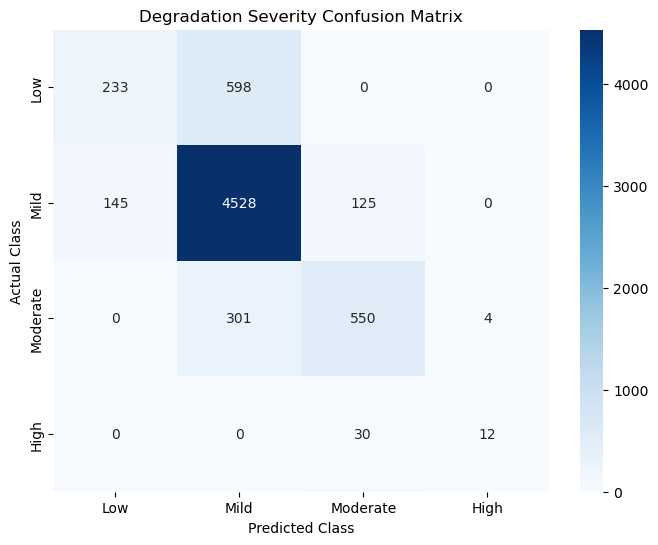

In [27]:
# Confusion matrix

cm = confusion_matrix(
    y_test_class,
    y_pred_class,
    labels=['Low', 'Mild', 'Moderate', 'High']
)

# Plot confusion matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Mild', 'Moderate', 'High'],
    yticklabels=['Low', 'Mild', 'Moderate', 'High']
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Degradation Severity Confusion Matrix")

plt.show()

## 19. SHAP Explainability Analysis

SHAP analysis is used to interpret model predictions and identify how different operational variables contribute to degradation risk.

In [29]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(xgb_regressor)

# Generate SHAP values
shap_values = explainer(X_test)

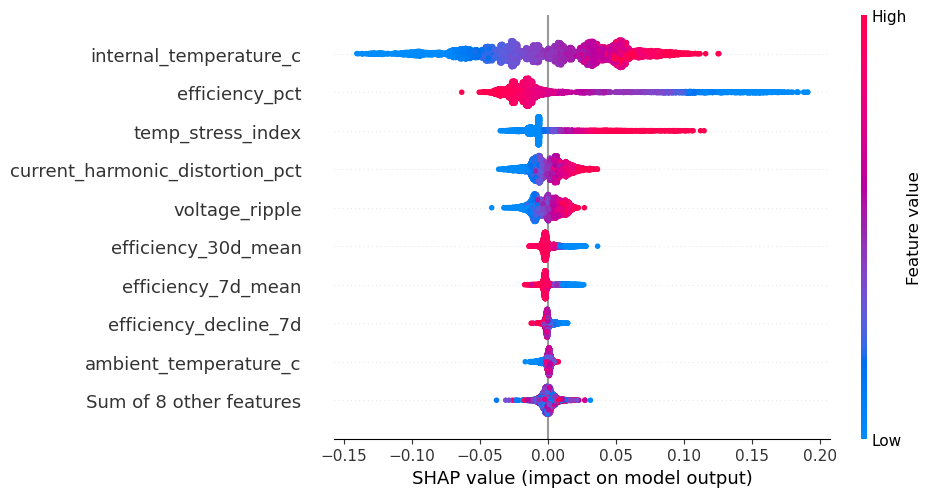

In [30]:
# SHAP summary plot

shap.plots.beeswarm(shap_values)

## 20. Maintenance Recommendation Engine

Operational maintenance recommendations are generated dynamically based on degradation severity levels to simulate real-world renewable energy asset management workflows.

In [31]:
# Maintenance recommendation logic

def maintenance_action(level):

    if level == "Low":
        return "Normal operation - continue monitoring"

    elif level == "Mild":
        return "Schedule inspection within 30 days"

    elif level == "Moderate":
        return "Perform maintenance inspection within 14 days"

    else:
        return "Immediate inspection and cleaning recommended"

# Apply recommendations
df['maintenance_recommendation'] = df['degradation_level'].apply(
    maintenance_action
)

# Preview recommendations
df[[
    'degradation_score',
    'degradation_level',
    'maintenance_recommendation'
]].head()

,degradation_score,degradation_level,maintenance_recommendation
0,0.312718,Mild,Schedule inspection within 30 days
1,0.359871,Mild,Schedule inspection within 30 days
2,0.361464,Mild,Schedule inspection within 30 days
3,0.445403,Mild,Schedule inspection within 30 days
4,0.334770,Mild,Schedule inspection within 30 days


## 21. Final Operational Output

The final output combines degradation predictions, severity classifications, and maintenance recommendations into an operational asset monitoring format.

In [32]:
# Final operational output table

final_output = df[[
    'date',
    'inverter_id',
    'efficiency_pct',
    'internal_temperature_c',
    'degradation_score',
    'degradation_level',
    'maintenance_recommendation'
]].copy()

# Preview output
final_output.head(10)

,date,inverter_id,efficiency_pct,internal_temperature_c,degradation_score,degradation_level,maintenance_recommendation
0,2025-01-01,INV-0001,97.93,28.51,0.312718,Mild,Schedule inspection within 30 days
1,2025-01-02,INV-0001,97.46,36.64,0.359871,Mild,Schedule inspection within 30 days
2,2025-01-03,INV-0001,98.04,32.22,0.361464,Mild,Schedule inspection within 30 days
3,2025-01-04,INV-0001,97.48,35.10,0.445403,Mild,Schedule inspection within 30 days
4,2025-01-05,INV-0001,98.43,36.49,0.334770,Mild,Schedule inspection within 30 days
5,2025-01-06,INV-0001,97.79,31.56,0.304404,Mild,Schedule inspection within 30 days
6,2025-01-07,INV-0001,97.52,33.16,0.429343,Mild,Schedule inspection within 30 days
7,2025-01-08,INV-0001,98.21,36.56,0.396215,Mild,Schedule inspection within 30 days
8,2025-01-09,INV-0001,97.54,41.78,0.388091,Mild,Schedule inspection within 30 days
9,2025-01-10,INV-0001,98.18,37.29,0.399461,Mild,Schedule inspection within 30 days


## 22. Export Results

The final degradation monitoring outputs are exported for operational reporting and dashboard integration.

In [33]:
# Export results

final_output.to_csv(
    "panel_degradation_results.csv",
    index=False
)

print("Results exported successfully.")

Results exported successfully.


# 23. Project Summary

This prototype successfully demonstrates a machine learning-based panel degradation detection system using synthetic SCADA and environmental telemetry data.

The workflow integrates:

- synthetic degradation simulation
- feature engineering
- weather-normalised degradation modelling
- XGBoost regression
- residual analysis
- rolling degradation indicators
- severity classification
- SHAP explainability
- operational maintenance recommendations

The model achieved strong predictive performance and identified operational efficiency, internal temperature, and thermal stress as the primary degradation drivers.

The system demonstrates how AI-driven renewable energy analytics can support proactive maintenance planning, improve operational efficiency, and reduce long-term solar asset degradation risks.